In [1]:
from __future__ import annotations

import math
import random
import warnings
from dataclasses import dataclass
import time

import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point

import osmnx as ox


import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=UserWarning)

/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
CITY_NAME = "Saint Petersburg, Russia"
OVERPASS_TIMEOUT = 240
OVERPASS_MEMORY = 1073741824
USE_CACHE = True
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

WALK_RADIUS_M = 800
COMMERCIAL_RADIUS_M = 1200
#SAMPLE_POINTS = 800   
MODEL_PATH = "spb_commercial_model2.joblib"
DATASET_PATH = "spb_training_dataset2.csv"
POI_EXPORT_PATH = "spb_pois2.gpkg"
ox.settings.use_cache = USE_CACHE
ox.settings.log_console = True
ox.settings.timeout = OVERPASS_TIMEOUT

In [3]:
BUSINESS_PROFILES = {
    "coffee_shop": {
        "competition_tags": ["cafe", "coffee", "fast_food", "bakery"],
        "demand_tags": ["office", "university", "school", "station", "bus_stop", "subway_entrance"],
        "support_tags": ["park", "hotel", "museum", "attraction", "retail"],
    },
    "restaurant": {
        "competition_tags": ["restaurant", "cafe", "fast_food", "bar", "pub"],
        "demand_tags": ["office", "hotel", "university", "museum", "attraction", "cinema"],
        "support_tags": ["parking", "park", "station", "subway_entrance", "bus_stop"],
    },
    "fitness_studio": {
        "competition_tags": ["fitness", "sports_centre", "swimming_pool", "yoga", "dance", "pilates", "crossfit"],
        "demand_tags": ["residential", "apartments", "office", "university", "school", "kindergarten", "hotel"],
        "support_tags": ["parking", "cafe", "restaurant", "health_food", "beauty", "clothing", "supermarket"],
    },
    "beauty_salon": {
        "competition_tags": ["beauty", "hairdresser", "cosmetics"],
        "demand_tags": ["office", "residential", "retail", "mall", "fitness"],
        "support_tags": ["parking", "bus_stop", "subway_entrance", "cafe"],
    },
    "dentist": {
        "competition_tags": ["dentist", "clinic", "doctors"],
        "demand_tags": ["residential", "apartments", "office", "clinic", "hospital", "doctors"],
        "support_tags": ["parking", "bus_stop", "subway_entrance", "pharmacy"],
    },
}

In [4]:
BUSINESS_RANKING_WEIGHTS = {
    "coffee_shop": {
        "total_pois_walk": 0.1430,
        "diversity_walk": 0.0877,
        "demand_count": 0.3224,
        "support_count": 0.0527,
        "competition_count": 0.0527,
        "dist_to_metro_m": 0.2194,
        "dist_to_bus_m": 0.0344,
        "intersection_density": 0.0877,
    },
    "restaurant": {
        "total_pois_walk": 0.1445,
        "diversity_walk": 0.0903,
        "demand_count": 0.3262,
        "support_count": 0.0564,
        "competition_count": 0.0418,
        "dist_to_metro_m": 0.2238,
        "dist_to_bus_m": 0.0318,
        "intersection_density": 0.0852,
    },
    "beauty_salon": {
        "total_pois_walk": 0.0987,
        "diversity_walk": 0.0721,
        "demand_count": 0.3023,
        "support_count": 0.0605,
        "competition_count": 0.1449,
        "dist_to_metro_m": 0.2247,
        "dist_to_bus_m": 0.0331,
        "intersection_density": 0.0637,
    },
    "fitness_studio": {
        "total_pois_walk": 0.0958,
        "diversity_walk": 0.0690,
        "demand_count": 0.3191,
        "support_count": 0.0481,
        "competition_count": 0.1418,
        "dist_to_metro_m": 0.2255,
        "dist_to_bus_m": 0.0325,
        "intersection_density": 0.0682,
    },
    "dentist": {
        "total_pois_walk": 0.0825,
        "diversity_walk": 0.0565,
        "demand_count": 0.2898,
        "support_count": 0.1056,
        "competition_count": 0.1519,
        "dist_to_metro_m": 0.2245,
        "dist_to_bus_m": 0.0308,
        "intersection_density": 0.0583,
    }
}

In [5]:
def first_existing_tag(row: pd.Series, candidates):
    for col in candidates:
        if col in row and pd.notna(row[col]):
            return str(row[col])
    return "unknown"


def ensure_points(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.centroid
    return gdf


def normalize_series(series: pd.Series) -> pd.Series:
    if series.max() - series.min() == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())


def safe_log1p(x):
    return float(np.log1p(max(0, x)))

### Загрузка границы города

In [6]:
def load_city_boundary(city_name: str = CITY_NAME) -> gpd.GeoDataFrame:
    print("Загружаем границу города")
    boundary = ox.geocode_to_gdf(city_name)
    print("Граница загружена")
    return boundary

In [7]:
boundary = load_city_boundary()
print(boundary[["display_name", "geometry"]].head(1))
print("CRS:", boundary.crs)

Загружаем границу города
Граница загружена
                                        display_name  \
0  Saint Petersburg, Northwestern Federal Distric...   

                                            geometry  
0  MULTIPOLYGON (((29.42576 60.19074, 29.42719 60...  
CRS: epsg:4326


In [8]:
#Загрузка пешеходной сети
def load_city_walk_graph(city_name: str = CITY_NAME):
    print("Загружаем пешеходную сеть")
    G = ox.graph_from_place(city_name, network_type="walk", simplify=True)
    print("Пешеходная сеть загружена")
    return G

In [9]:
G = load_city_walk_graph()
print(type(G))
print("Число узлов:", len(G.nodes))
print("Число ребер:", len(G.edges))

Загружаем пешеходную сеть
Пешеходная сеть загружена
<class 'networkx.classes.multidigraph.MultiDiGraph'>
Число узлов: 415604
Число ребер: 1154950


In [10]:
#Перборазование графа из географических координат в метрическую
def prepare_projected_graph(G):
    print("Проецируем граф в метрическую систему")
    G_proj = ox.project_graph(G, to_crs="EPSG:3857")
    print("Граф спроецирован")
    return G_proj

In [11]:
G_proj = prepare_projected_graph(G)
nodes, edges = ox.graph_to_gdfs(G_proj)
print(nodes.crs)
print(edges.crs)

Проецируем граф в метрическую систему
Граф спроецирован
EPSG:3857
EPSG:3857


### POI

In [12]:
def _download_pois_chunk(city_name: str, tags: dict, pause_sec: float = 2.0, max_retries: int = 3):
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            print(f"  -> запрос {attempt}/{max_retries}: {tags}")
            gdf = ox.features_from_place(city_name, tags)
            time.sleep(pause_sec)
            return gdf
        except Exception as e:
            last_error = e
            wait_time = pause_sec * attempt * 2
            print(f"ошибка: {e}")
            print(f"повтор через {wait_time:.1f} сек")
            time.sleep(wait_time)

    raise RuntimeError(f"Не удалось скачать chunk {tags}: {last_error}")

In [14]:
def canonicalize_poi_category(row: pd.Series) -> str:
    amenity = row.get("amenity")
    shop = row.get("shop")
    tourism = row.get("tourism")
    leisure = row.get("leisure")
    office = row.get("office")
    public_transport = row.get("public_transport")
    railway = row.get("railway")
    building = row.get("building")
    landuse = row.get("landuse")
    healthcare = row.get("healthcare")
    highway = row.get("highway")
    sport = row.get("sport")

    def val(x):
        return str(x) if pd.notna(x) else None

    amenity = val(amenity)
    shop = val(shop)
    tourism = val(tourism)
    leisure = val(leisure)
    office = val(office)
    public_transport = val(public_transport)
    railway = val(railway)
    building = val(building)
    landuse = val(landuse)
    healthcare = val(healthcare)
    highway = val(highway)
    sport = val(sport)

    # Транспорт
    if highway == "bus_stop" or public_transport in {"platform", "stop_position"} or amenity == "bus_station":
        return "bus_stop"
    if railway == "subway_entrance":
        return "subway_entrance"
    if railway in {"station", "halt"} or public_transport == "station":
        return "station"

    # Офисы — сводим все office=* к одной категории
    if office is not None:
        return "office"

    # Жилая среда
    if building in {"apartments", "residential"}:
        return building
    if landuse in {"residential", "retail"}:
        return landuse

    # Медицинские объекты
    if healthcare in {"clinic", "hospital", "dentist", "doctors", "pharmacy"}:
        return healthcare
    if amenity in {"clinic", "hospital", "dentist", "doctors", "pharmacy"}:
        return amenity

    # Образование / общественные объекты
    if amenity in {"school", "university", "kindergarten", "parking", "cinema"}:
        return amenity

    # HoReCa
    if amenity in {"cafe", "restaurant", "fast_food", "bar", "pub", "bakery"}:
        return amenity
    if shop in {"coffee", "bakery"}:
        return shop

    # Туризм
    if tourism in {"hotel", "museum", "attraction"}:
        return tourism
    if leisure == "park":
        return "park"

    # Фитнес и спорт
    if leisure == "fitness_centre":
        return "fitness"
    if leisure in {"sports_centre", "swimming_pool"}:
        return leisure
    if sport in {"fitness", "yoga", "pilates", "dance", "swimming", "crossfit"}:
        if sport == "fitness":
            return "fitness"
        if sport == "swimming":
            return "swimming_pool"
        return sport

    # Бьюти
    if shop in {"beauty", "hairdresser", "cosmetics", "mall", "supermarket", "health_food"}:
        return shop
    if shop == "clothes":
        return "clothing"

    for x in [amenity, shop, tourism, leisure, healthcare, landuse, building, sport]:
        if x is not None:
            return x

    return "unknown"

In [15]:
def _postprocess_pois(pois: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if pois.empty:
        raise ValueError("POI GeoDataFrame пустой после загрузки")

    pois = pois.reset_index(drop=False)

    if "geometry" not in pois.columns:
        raise ValueError("Не удалось получить geometry из OSM")

    pois = pois.to_crs(3857)
    pois = ensure_points(pois)

    for col in [
        "amenity", "shop", "tourism", "leisure", "office",
        "public_transport", "railway", "building", "landuse",
        "healthcare", "highway", "sport"
    ]:
        if col not in pois.columns:
            pois[col] = np.nan

    pois["poi_category_raw"] = pois.apply(
        lambda row: first_existing_tag(
            row,
            [
                "amenity", "shop", "tourism", "leisure", "office",
                "public_transport", "railway", "healthcare",
                "landuse", "building", "highway", "sport"
            ]
        ),
        axis=1
    )

    pois["poi_category"] = pois.apply(canonicalize_poi_category, axis=1)

    pois["is_retail"] = pois["shop"].notna().astype(int)

    pois["is_food"] = pois["poi_category"].isin(
        ["cafe", "restaurant", "fast_food", "bar", "pub", "bakery"]
    ).astype(int)

    pois["is_transit"] = pois["poi_category"].isin(
        ["bus_stop", "station", "subway_entrance"]
    ).astype(int)

    return pois

In [16]:
def load_city_pois(city_name: str = CITY_NAME) -> gpd.GeoDataFrame:
    print("Загружаем POI")

    tag_chunks = [
        {"amenity": True},
        {"shop": True},
        {"tourism": True},
        {"office": True},
        {"public_transport": True, "railway": True, "highway": "bus_stop"},
        {"leisure": True},
        {"sport": True},
        {"healthcare": True},
        {"building": True},
        {"landuse": True},
    ]

    chunks = []
    failed_chunks = []

    for tags in tag_chunks:
        try:
            chunk = _download_pois_chunk(city_name, tags)
            if chunk is not None and not chunk.empty:
                chunks.append(chunk)
        except Exception as e:
            failed_chunks.append((tags, str(e)))
            print(f"  !! chunk пропущен: {tags}")

    if len(chunks) == 0:
        raise RuntimeError("Не удалось загрузить ни одного чанка POI")

    pois = pd.concat(chunks, axis=0)
    pois = gpd.GeoDataFrame(pois, geometry="geometry", crs=chunks[0].crs)
    pois = _postprocess_pois(pois)

    print(f"POI загружены: {len(pois)}")
    if failed_chunks:
        print("Часть чанков не загрузилась:")
        for tags, err in failed_chunks:
            print(tags, "->", err)

    return pois

In [17]:
pois = load_city_pois()
print(pois[["poi_category", "geometry"]].head())
print("Всего POI:", len(pois))
print("Типы POI:", pois["poi_category"].nunique())

Загружаем POI
  -> запрос 1/3: {'amenity': True}
  -> запрос 1/3: {'shop': True}
  -> запрос 1/3: {'tourism': True}
  -> запрос 1/3: {'office': True}
  -> запрос 1/3: {'public_transport': True, 'railway': True, 'highway': 'bus_stop'}
  -> запрос 1/3: {'leisure': True}
  -> запрос 1/3: {'sport': True}
  -> запрос 1/3: {'healthcare': True}
  -> запрос 1/3: {'building': True}
  -> запрос 1/3: {'landuse': True}
POI загружены: 423765
     poi_category                         geometry
0         station  POINT (3314043.613 8396348.947)
1  ferry_terminal  POINT (3307619.688 8400982.391)
2  ferry_terminal  POINT (3368696.363 8381816.119)
3            fuel  POINT (3387649.463 8406842.943)
4      restaurant  POINT (3333094.397 8427217.143)
Всего POI: 423765
Типы POI: 711


In [18]:
def audit_business_profiles(pois: gpd.GeoDataFrame, profiles: dict) -> pd.DataFrame:
    observed = set(pois["poi_category"].dropna().astype(str).unique())

    rows = []
    for business_type, profile in profiles.items():
        for group_name in ["competition_tags", "demand_tags", "support_tags"]:
            for tag in profile[group_name]:
                count = int((pois["poi_category"] == tag).sum())
                rows.append({
                    "business_type": business_type,
                    "group": group_name,
                    "tag": tag,
                    "present_in_pois": tag in observed,
                    "count_in_city": count,
                })

    result = pd.DataFrame(rows)
    return result.sort_values(["present_in_pois", "count_in_city", "business_type", "group", "tag"])

audit_df = audit_business_profiles(pois, BUSINESS_PROFILES)
display(audit_df)

,business_type,group,tag,present_in_pois,count_in_city
36,fitness_studio,competition_tags,pilates,False,0
37,fitness_studio,competition_tags,crossfit,True,2
34,fitness_studio,competition_tags,yoga,True,8
1,coffee_shop,competition_tags,coffee,True,23
48,fitness_studio,support_tags,health_food,True,26
...,...,...,...,...,...
8,coffee_shop,demand_tags,bus_stop,True,14036
74,dentist,support_tags,bus_stop,True,14036
30,restaurant,support_tags,bus_stop,True,14036
68,dentist,demand_tags,apartments,True,20401


In [19]:
def _download_feature_chunk(city_name: str, tags: dict, pause_sec: float = 1.5, max_retries: int = 3):
    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            print(f"  -> запрос {attempt}/{max_retries}: {tags}")
            gdf = ox.features_from_place(city_name, tags)
            time.sleep(pause_sec)
            return gdf
        except Exception as e:
            last_error = e
            wait_time = pause_sec * attempt * 2
            print(f"     ошибка: {e}")
            print(f"     повтор через {wait_time:.1f} сек...")
            time.sleep(wait_time)

    raise RuntimeError(f"Не удалось загрузить chunk {tags}: {last_error}")

In [21]:
def load_candidate_locations_fast(city_name: str = CITY_NAME) -> gpd.GeoDataFrame:
    print("Загружаем только коммерчески релевантные объекты")

    tag_chunks = [
        {"shop": True},
        {"amenity": True},
        {"office": True},
        {"building": ["commercial", "retail", "office", "mixed_use"]},
        {"addr:street": True, "addr:housenumber": True},
    ]

    chunks = []
    failed_chunks = []

    for tags in tag_chunks:
        try:
            chunk = _download_feature_chunk(city_name, tags)
            if chunk is not None and not chunk.empty:
                chunks.append(chunk)
        except Exception as e:
            failed_chunks.append((tags, str(e)))
            print(f"  !! chunk пропущен: {tags}")

    if not chunks:
        raise RuntimeError("Не удалось загрузить ни одного чанка кандидатных объектов.")

    gdf = pd.concat(chunks, axis=0)
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=chunks[0].crs)
    gdf = gdf.reset_index(drop=False)

    if "geometry" not in gdf.columns:
        raise ValueError("У объектов нет geometry.")

    # оставляем только точечные и полигональные объекты
    gdf = gdf[gdf.geometry.notna()].copy()
    gdf = gdf[gdf.geometry.geom_type.isin(["Point", "Polygon", "MultiPolygon"])].copy()

    # добавляем недостающие колонки
    for col in [
        "building", "name", "addr:street", "addr:housenumber",
        "shop", "amenity", "office"
    ]:
        if col not in gdf.columns:
            gdf[col] = np.nan

    # переводим в метры
    gdf = gdf.to_crs(3857)

    # сохраняем исходную геометрию
    gdf["source_geometry"] = gdf.geometry

    # если полигон — берем центроид, если точка — оставляем как есть
    gdf["geometry"] = gdf.geometry.apply(
        lambda geom: geom.centroid if geom.geom_type in ["Polygon", "MultiPolygon"] else geom
    )

    # флаг адреса
    gdf["has_address"] = gdf["addr:street"].notna() & gdf["addr:housenumber"].notna()

    # флаг коммерческого объекта
    gdf["is_business_candidate"] = (
        gdf["shop"].notna()
        | gdf["amenity"].notna()
        | gdf["office"].notna()
        | gdf["building"].isin(["commercial", "retail", "office", "mixed_use"])
    )

    # оставляем только действительно полезные кандидаты
    gdf = gdf[gdf["has_address"] | gdf["is_business_candidate"]].copy()

    # формируем адрес
    gdf["full_address"] = gdf.apply(
        lambda row: (
            f"{row['addr:street']}, {row['addr:housenumber']}, Санкт-Петербург"
            if pd.notna(row["addr:street"]) and pd.notna(row["addr:housenumber"])
            else None
        ),
        axis=1
    )

    dedup_cols = [c for c in ["element", "id", "osmid", "name"] if c in gdf.columns]
    if dedup_cols:
        gdf = gdf.drop_duplicates(subset=dedup_cols + ["geometry"])
    else:
        gdf = gdf.drop_duplicates(subset=["geometry"])

    gdf = gdf.reset_index(drop=True)

    print("Кандидатных объектов после фильтрации:", len(gdf))

    if failed_chunks:
        print("\nНе загрузились некоторые чанки:")
        for tags, err in failed_chunks:
            print(f" - {tags}: {err}")

    return gdf

In [22]:
candidate_locations = load_candidate_locations_fast()

print(candidate_locations.head(5))
print("CRS:", candidate_locations.crs)
print("Количество:", len(candidate_locations))

Загружаем только коммерчески релевантные объекты
  -> запрос 1/3: {'shop': True}
  -> запрос 1/3: {'amenity': True}
  -> запрос 1/3: {'office': True}
  -> запрос 1/3: {'building': ['commercial', 'retail', 'office', 'mixed_use']}
  -> запрос 1/3: {'addr:street': True, 'addr:housenumber': True}
Кандидатных объектов после фильтрации: 222857
  element         id                         geometry          name  \
0    node  247698216   POINT (3382751.45 8410199.866)        Магнит   
1    node  248465166    POINT (3385466.9 8402532.428)  Всё для дома   
2    node  248701411      POINT (3382532.229 8401363)           NaN   
3    node  253103143  POINT (3384447.358 8406880.851)          Леди   
4    node  271001484  POINT (3374514.676 8396340.735)   Передвижник   

          shop check_date name:signed amenity   brand brand:en  ...  \
0  supermarket        NaN         NaN     NaN  Магнит   Magnit  ...   
1          yes        NaN         NaN     NaN     NaN      NaN  ...   
2   car_repair      

In [23]:
def prepare_fast_context(pois: gpd.GeoDataFrame, G_proj):
    print("Готовим ускоренный контекст с пешеходной сетью")

    pois = pois.copy()
    _ = pois.sindex

    nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

    metro_mask = (
        pois["railway"].astype(str).isin(["station", "halt", "subway_entrance"])
        | pois["public_transport"].astype(str).isin(["station", "stop_position", "platform"])
    )

    bus_mask = (
        pois["highway"].astype(str).isin(["bus_stop"])
        | pois["amenity"].astype(str).isin(["bus_station"])
    )

    # Привязываем каждый POI к ближайшему узлу пешеходной сети
    pois["nearest_node"] = ox.distance.nearest_nodes(
        G_proj,
        X=pois.geometry.x.to_numpy(),
        Y=pois.geometry.y.to_numpy(),
    )

    # Индекс: узел графа -> список POI, привязанных к нему
    node_to_poi_idx = {}
    for idx, node_id in zip(pois.index, pois["nearest_node"]):
        node_to_poi_idx.setdefault(int(node_id), []).append(idx)

    context = {
        "pois": pois,
        "G_proj": G_proj,
        "nodes_proj": nodes_proj,
        "metro_mask": metro_mask,
        "bus_mask": bus_mask,
        "metro_nodes": set(pois.loc[metro_mask, "nearest_node"].astype(int).tolist()),
        "bus_nodes": set(pois.loc[bus_mask, "nearest_node"].astype(int).tolist()),
        "node_to_poi_idx": node_to_poi_idx,
    }

    print("Контекст готов")
    print("POI:", len(pois))
    print("Nodes:", len(nodes_proj))
    return context

In [24]:
fast_context = prepare_fast_context(pois, G_proj)

Готовим ускоренный контекст с пешеходной сетью
Контекст готов
POI: 423765
Nodes: 415604


In [25]:
def estimate_intersection_density_fast(G_proj, nodes_proj, point_proj: Point, radius_m: float = 500) -> float: #плотность пересечений вокруг точки (при заданном радиусе)
    buf = point_proj.buffer(radius_m)

    local_nodes = nodes_proj[nodes_proj.intersects(buf)]
    if local_nodes.empty:
        return 0.0

    degree_counts = dict(G_proj.degree(local_nodes.index))
    intersections = sum(1 for d in degree_counts.values() if d >= 3)

    area_km2 = math.pi * (radius_m / 1000) ** 2
    return intersections / max(area_km2, 1e-6)

In [27]:
def get_network_lengths_from_point(G_proj, point_proj: Point, cutoff_m: float) -> tuple[int, dict]:
    origin_node = ox.distance.nearest_nodes(G_proj, X=point_proj.x, Y=point_proj.y)

    lengths = nx.single_source_dijkstra_path_length(
        G_proj,
        origin_node,
        cutoff=cutoff_m,
        weight="length"
    )

    return int(origin_node), lengths


def extract_neighbors_network(context: dict, lengths: dict, radius_m: float) -> gpd.GeoDataFrame:
    pois = context["pois"]
    node_to_poi_idx = context["node_to_poi_idx"]

    candidate_idx = []
    for node_id, dist in lengths.items():
        if dist <= radius_m:
            candidate_idx.extend(node_to_poi_idx.get(int(node_id), []))

    if not candidate_idx:
        return pois.iloc[0:0].copy()

    nearby = pois.loc[candidate_idx].copy()
    nearby["network_distance_m"] = nearby["nearest_node"].map(lengths)

    nearby = nearby[
        nearby["network_distance_m"].notna()
        & (nearby["network_distance_m"] <= radius_m)
    ].copy()

    return nearby.sort_values("network_distance_m")


def nearest_distance_to_node_set(lengths: dict, target_nodes: set, default_m: float = 3000.0) -> float:
    reachable = [lengths[node_id] for node_id in target_nodes if node_id in lengths]
    if not reachable:
        return float(default_m)
    return float(min(reachable))


def compute_location_features_fast(
    point_proj: Point,
    business_type: str,
    context: dict,
    walk_radius_m: float = 800,
    commercial_radius_m: float = 1200,
    transit_search_radius_m: float = 3000,
) -> dict:

    pois = context["pois"]
    G_proj = context["G_proj"]
    nodes_proj = context["nodes_proj"]
    metro_nodes = context["metro_nodes"]
    bus_nodes = context["bus_nodes"]

    if business_type not in BUSINESS_PROFILES:
        raise ValueError(f"Неизвестный тип бизнеса: {business_type}")

    profile = BUSINESS_PROFILES[business_type]

    cutoff_m = max(walk_radius_m, commercial_radius_m, transit_search_radius_m)
    _, lengths = get_network_lengths_from_point(G_proj, point_proj, cutoff_m=cutoff_m)

    nearby_walk = extract_neighbors_network(context, lengths, walk_radius_m)
    nearby_comm = extract_neighbors_network(context, lengths, commercial_radius_m)

    category_counts_walk = nearby_walk["poi_category"].value_counts().to_dict()
    category_counts_comm = nearby_comm["poi_category"].value_counts().to_dict()

    total_pois_walk = float(len(nearby_walk))
    total_pois_comm = float(len(nearby_comm))

    diversity_walk = float(nearby_walk["poi_category"].nunique()) if not nearby_walk.empty else 0.0
    diversity_comm = float(nearby_comm["poi_category"].nunique()) if not nearby_comm.empty else 0.0

    retail_count = float(nearby_comm["is_retail"].sum()) if "is_retail" in nearby_comm.columns else 0.0
    food_count = float(nearby_comm["is_food"].sum()) if "is_food" in nearby_comm.columns else 0.0
    transit_count = float(nearby_walk["is_transit"].sum()) if "is_transit" in nearby_walk.columns else 0.0

    dist_to_metro = nearest_distance_to_node_set(lengths, metro_nodes, default_m=transit_search_radius_m)
    dist_to_bus = nearest_distance_to_node_set(lengths, bus_nodes, default_m=transit_search_radius_m)

    competition_count = sum(category_counts_comm.get(tag, 0) for tag in profile["competition_tags"])
    demand_count = sum(category_counts_comm.get(tag, 0) for tag in profile["demand_tags"])
    support_count = sum(category_counts_comm.get(tag, 0) for tag in profile["support_tags"])

    intersection_density = estimate_intersection_density_fast(
        G_proj=G_proj,
        nodes_proj=nodes_proj,
        point_proj=point_proj,
        radius_m=500
    )

    features = {
        "business_type": business_type,
        "total_pois_walk": total_pois_walk,
        "total_pois_comm": total_pois_comm,
        "diversity_walk": diversity_walk,
        "diversity_comm": diversity_comm,
        "retail_count": retail_count,
        "food_count": food_count,
        "transit_count": transit_count,
        "dist_to_metro_m": dist_to_metro,
        "dist_to_bus_m": dist_to_bus,
        "competition_count": float(competition_count),
        "demand_count": float(demand_count),
        "support_count": float(support_count),
        "intersection_density": float(intersection_density),
    }

    return features

In [28]:
def prepare_candidate_points(candidate_locations: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    print("Готовим candidate_points")

    candidate_points = candidate_locations.copy()

    # оставляем только объекты с валидной геометрией
    candidate_points = candidate_points[candidate_points.geometry.notna()].copy()

    # на этом этапе geometry уже должна быть Point
    candidate_points = candidate_points[
        candidate_points.geometry.geom_type == "Point"
    ].copy()

    # создаем уникальный id
    candidate_points = candidate_points.reset_index(drop=True)
    candidate_points["sample_id"] = range(len(candidate_points))

    # порядок колонок
    preferred_cols = [
        "sample_id",
        "name",
        "building",
        "shop",
        "amenity",
        "office",
        "addr:street",
        "addr:housenumber",
        "full_address",
        "has_address",
        "is_business_candidate",
        "geometry",
    ]

    existing_cols = [c for c in preferred_cols if c in candidate_points.columns]
    other_cols = [c for c in candidate_points.columns if c not in existing_cols]

    candidate_points = candidate_points[existing_cols + other_cols].copy()

    print("Кандидатных точек подготовлено:", len(candidate_points))
    return candidate_points

In [29]:
candidate_points = prepare_candidate_points(candidate_locations)

print(candidate_points.head(5))
print("CRS:", candidate_points.crs)
print("Количество точек:", len(candidate_points))

Готовим candidate_points
Кандидатных точек подготовлено: 222857
   sample_id          name building         shop amenity office  \
0          0        Магнит      NaN  supermarket     NaN    NaN   
1          1  Всё для дома      NaN          yes     NaN    NaN   
2          2           NaN      NaN   car_repair     NaN    NaN   
3          3          Леди      NaN       beauty     NaN    NaN   
4          4   Передвижник      NaN        craft     NaN    NaN   

               addr:street addr:housenumber  \
0                      NaN              NaN   
1                      NaN              NaN   
2                      NaN              NaN   
3                      NaN              NaN   
4  набережная Чёрной речки               25   

                                   full_address  has_address  ...  \
0                                          None        False  ...   
1                                          None        False  ...   
2                                          

In [30]:
def sample_candidate_points(candidate_points: gpd.GeoDataFrame, max_points: int = 200) -> gpd.GeoDataFrame:
    print("Делаем подвыборку candidate_points")

    if len(candidate_points) <= max_points:
        sampled = candidate_points.copy()
    else:
        sampled = candidate_points.sample(max_points, random_state=42).copy()

    sampled = sampled.reset_index(drop=True)
    print("Точек в подвыборке:", len(sampled))
    return sampled

In [31]:
candidate_points_sample = sample_candidate_points(candidate_points, max_points=150)

print(candidate_points_sample.head(5))
print("Количество:", len(candidate_points_sample))

Делаем подвыборку candidate_points
Точек в подвыборке: 150
   sample_id           name   building     shop  amenity office  \
0     185672            NaN  dormitory      NaN      NaN    NaN   
1      37598            NaN        NaN      NaN      atm    NaN   
2     104523          Поинт        NaN      NaN     cafe    NaN   
3       9828  Ароматный мир        NaN  alcohol      NaN    NaN   
4     119269            NaN        NaN      NaN  parking    NaN   

             addr:street addr:housenumber  \
0        улица Рябчикова       11 к2 литБ   
1                    NaN              NaN   
2  улица Ярослава Гашека            19 с1   
3                    NaN              NaN   
4                    NaN              NaN   

                                    full_address  has_address  ...  \
0   улица Рябчикова, 11 к2 литБ, Санкт-Петербург         True  ...   
1                                           None        False  ...   
2  улица Ярослава Гашека, 19 с1, Санкт-Петербург         

In [32]:
def build_small_dataset_from_real_points_fast(
    candidate_points_sample: gpd.GeoDataFrame,
    context: dict,
    business_types=None,
    report_every: int = 20
) -> pd.DataFrame:
    print("Считаем признаки по подвыборке реальных точек")

    if business_types is None:
        business_types = [
            "coffee_shop",
            "restaurant",
            "fitness_studio",
            "beauty_salon",
            "dentist",
        ]

    records = []

    total_points = len(candidate_points_sample)

    for i, (_, row) in enumerate(candidate_points_sample.iterrows(), start=1):
        point_proj = row.geometry

        for business_type in business_types:
            try:
                features = compute_location_features_fast(
                    point_proj=point_proj,
                    business_type=business_type,
                    context=context
                )

                features["sample_id"] = int(row["sample_id"])

                if "full_address" in row:
                    features["full_address"] = row["full_address"]

                if "name" in row:
                    features["location_name"] = row["name"]

                records.append(features)

            except Exception as e:
                print(f"Ошибка на sample_id={row['sample_id']}, business_type={business_type}: {e}")

        if i % report_every == 0 or i == total_points:
            print(f"Обработано точек: {i}/{total_points}")

    df = pd.DataFrame(records)
    print("Строк в датасете:", len(df))
    return df

In [34]:
dataset_real_small = build_small_dataset_from_real_points_fast(
    candidate_points_sample=candidate_points_sample,
    context=fast_context,
    business_types=["coffee_shop", "restaurant", "fitness_studio", "beauty_salon", 'dentist'],
    report_every=25
)

print(dataset_real_small.shape)
display(dataset_real_small.head(10))

Считаем признаки по подвыборке реальных точек
Обработано точек: 25/150
Обработано точек: 50/150
Обработано точек: 75/150
Обработано точек: 100/150
Обработано точек: 125/150
Обработано точек: 150/150
Строк в датасете: 750
(750, 17)


,business_type,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,competition_count,demand_count,support_count,intersection_density,sample_id,full_address,location_name
0,coffee_shop,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,17.0,50.0,12.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN
1,restaurant,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,15.0,23.0,53.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN
2,fitness_studio,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,11.0,92.0,52.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN
3,beauty_salon,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,7.0,54.0,60.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN
4,dentist,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,8.0,93.0,60.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN
5,coffee_shop,2126.0,4283.0,169.0,214.0,630.0,244.0,52.0,30.065145,30.065145,209.0,392.0,88.0,264.833825,37598,None,NaN
6,restaurant,2126.0,4283.0,169.0,214.0,630.0,244.0,52.0,30.065145,30.065145,229.0,289.0,198.0,264.833825,37598,None,NaN
7,fitness_studio,2126.0,4283.0,169.0,214.0,630.0,244.0,52.0,30.065145,30.065145,23.0,592.0,294.0,264.833825,37598,None,NaN
8,beauty_salon,2126.0,4283.0,169.0,214.0,630.0,244.0,52.0,30.065145,30.065145,88.0,306.0,280.0,264.833825,37598,None,NaN
9,dentist,2126.0,4283.0,169.0,214.0,630.0,244.0,52.0,30.065145,30.065145,162.0,592.0,214.0,264.833825,37598,None,NaN


In [35]:
def add_engineered_target(df: pd.DataFrame) -> pd.DataFrame:
    print("Добавляем target")
    df = df.copy()

    weights = BUSINESS_RANKING_WEIGHTS
    score_raw = np.zeros(len(df))

    for business_type in df['business_type'].unique():
        mask = df['business_type'] == business_type
        w = weights.get(business_type)

        if w is None:
            raise ValueError(f"Нет весов для {business_type}")

        score_raw[mask] = (
            w['total_pois_walk'] * np.log1p(df.loc[mask, "total_pois_walk"]) +
            w['diversity_walk'] * np.log1p(df.loc[mask, "diversity_walk"]) +
            w['demand_count'] * np.log1p(df.loc[mask, "demand_count"]) +
            w['support_count'] * np.log1p(df.loc[mask, "support_count"]) +
            w['competition_count'] * np.log1p(df.loc[mask, "competition_count"]) +
            w['dist_to_metro_m'] * (1 / (1 + df.loc[mask, "dist_to_metro_m"] / 400)) +
            w['dist_to_bus_m'] * (1 / (1 + df.loc[mask, "dist_to_bus_m"] / 250)) +
            w['intersection_density'] * np.log1p(df.loc[mask, "intersection_density"])
        )

    df["commercial_score_raw"] = score_raw
    df["commercial_score"] = np.nan

    for business_type in df["business_type"].unique():
        mask = df["business_type"] == business_type

        min_s = df.loc[mask, "commercial_score_raw"].min()
        max_s = df.loc[mask, "commercial_score_raw"].max()

        if max_s - min_s == 0:
            df.loc[mask, "commercial_score"] = 50.0
        else:
            df.loc[mask, "commercial_score"] = (
                100 * (df.loc[mask, "commercial_score_raw"] - min_s) / (max_s - min_s)
            )

    df["commercial_class"] = pd.cut(
        df["commercial_score"],
        bins=[-0.01, 35.00, 75.00, 100.0],
        labels=["low", "medium", "high"]
    )

    print("Таргет добавлен")
    return df

In [36]:
dataset_real_small = add_engineered_target(dataset_real_small)

print(dataset_real_small.shape)
display(dataset_real_small[[
    "sample_id",
    "business_type",
    "commercial_score_raw",
    "commercial_score",
    "commercial_class"
]].head(10))

Добавляем target
Таргет добавлен
(750, 20)


,sample_id,business_type,commercial_score_raw,commercial_score,commercial_class
0,185672,coffee_shop,3.192845,54.018009,medium
1,185672,restaurant,3.026920,48.502177,medium
2,185672,fitness_studio,3.203935,58.362501,medium
3,185672,beauty_salon,2.989046,52.670838,medium
4,185672,dentist,3.131771,55.509398,medium
5,37598,coffee_shop,4.714829,94.492788,high
6,37598,restaurant,4.658560,92.102793,high
7,37598,fitness_studio,4.469640,93.337689,high
8,37598,beauty_salon,4.443494,93.326592,high
9,37598,dentist,4.675416,95.588846,high


In [37]:
dataset_real_small["commercial_score"].describe()

count    750.000000
mean      66.326548
std       19.502162
min        0.000000
25%       57.104379
50%       70.250062
75%       79.117296
max      100.000000
Name: commercial_score, dtype: float64

In [38]:
dataset_real_small["commercial_class"].value_counts()

commercial_class
medium    402
high      278
low        68
Name: count, dtype: int64

### Кластеризация

In [39]:
CLUSTER_FEATURES = [
    "total_pois_walk",
    "total_pois_comm",
    "diversity_walk",
    "diversity_comm",
    "retail_count",
    "food_count",
    "transit_count",
    "dist_to_metro_m",
    "dist_to_bus_m",
    "intersection_density",
]

RANKING_FEATURES = sorted({
    feat
    for weights in BUSINESS_RANKING_WEIGHTS.values()
    for feat in weights.keys()
})

In [40]:
def prepare_cluster_data_from_locations(df: pd.DataFrame, feature_cols=None):
    print("Подготовка данных для PCA + clustering по локациям")

    if feature_cols is None:
        feature_cols = CLUSTER_FEATURES

    work_df = df.copy()

    cols_needed = ["sample_id"] + feature_cols
    if "full_address" in work_df.columns:
        cols_needed.append("full_address")
    if "location_name" in work_df.columns:
        cols_needed.append("location_name")

    cols_needed = [c for c in cols_needed if c in work_df.columns]
    work_df = work_df[cols_needed].copy()

    work_df = work_df.dropna(subset=feature_cols).reset_index(drop=True)

    # одна локация = одна строка
    agg_map = {col: "first" for col in feature_cols}
    if "full_address" in work_df.columns:
        agg_map["full_address"] = "first"
    if "location_name" in work_df.columns:
        agg_map["location_name"] = "first"

    cluster_df = (
        work_df
        .groupby("sample_id", as_index=False)
        .agg(agg_map)
        .reset_index(drop=True)
    )

    X = cluster_df[feature_cols].copy()

    print("Размер таблицы локаций:", cluster_df.shape)
    print("Размер X:", X.shape)

    return cluster_df, X, feature_cols

In [41]:
unsup_df, X_unsup, unsup_features = prepare_cluster_data_from_locations(
    dataset_real_small,
    feature_cols=CLUSTER_FEATURES
)
display(unsup_df.head())

Подготовка данных для PCA + clustering по локациям
Размер таблицы локаций: (150, 13)
Размер X: (150, 10)


,sample_id,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,intersection_density,full_address,location_name
0,2785,106.0,267.0,21.0,36.0,11.0,0.0,12.0,0.000000,0.000000,15.278875,None,Магазин автозапчастей
1,2863,1829.0,4259.0,155.0,220.0,636.0,294.0,61.0,296.922927,331.976429,259.740867,None,Магнит
2,3227,2283.0,4605.0,189.0,236.0,995.0,342.0,46.0,184.055416,184.055416,303.031012,None,Ароматный мир
3,4298,517.0,1010.0,51.0,62.0,33.0,13.0,30.0,6.129248,343.935876,103.132403,None,Юпитер
4,4480,2253.0,4553.0,179.0,213.0,758.0,456.0,67.0,73.636283,73.636283,267.380304,None,Презент


In [42]:
def scale_unsupervised_features(X: pd.DataFrame):
    print("Стандартизация признаков")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    print("Стандартизация завершена")
    return scaler, X_scaled_df

In [43]:
scaler_unsup, X_scaled_df = scale_unsupervised_features(X_unsup)
display(X_scaled_df.head())

Стандартизация признаков
Стандартизация завершена


,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,intersection_density
0,-1.481208,-1.555598,-1.587128,-1.702609,-1.006577,-0.752346,-1.002243,-1.072043,-1.112764,-1.507892
1,1.609151,1.958711,1.434399,1.696451,1.611735,1.958756,1.648526,0.282939,0.354973,0.864666
2,2.423441,2.263308,2.201055,1.992022,3.115694,2.401385,0.837066,-0.232123,-0.299017,1.284806
3,-0.744042,-0.901507,-0.910667,-1.222307,-0.914412,-0.632467,-0.028491,-1.044073,0.407848,-0.655254
4,2.369634,2.217530,1.975568,1.567139,2.122830,3.452628,1.973110,-0.736011,-0.787203,0.938808


In [44]:
def fit_pca_full(X_scaled_df: pd.DataFrame):

    pca_full = PCA()
    pca_full.fit(X_scaled_df)

    explained = pd.DataFrame({
        "component": np.arange(1, len(X_scaled_df.columns) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca_full.explained_variance_ratio_)
    })

    return pca_full, explained

In [45]:
pca_full, pca_explained_df = fit_pca_full(X_scaled_df)
display(pca_explained_df)

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.652339,0.652339
1,2,0.164236,0.816575
2,3,0.070390,0.886965
3,4,0.042631,0.929596
4,5,0.031898,0.961494
5,6,0.020045,0.981539
6,7,0.006642,0.988181
7,8,0.005519,0.993700
8,9,0.004699,0.998400
9,10,0.001600,1.000000


In [46]:
def fit_pca_selected(X_scaled_df: pd.DataFrame, n_components: int = 4):
    print(f"Обучаем PCA с n_components={n_components}...")

    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled_df)

    pca_cols = [f"PC{i+1}" for i in range(n_components)]
    X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X_scaled_df.index)

    print("Доля объясненной дисперсии:", pca.explained_variance_ratio_)
    print("Суммарно:", pca.explained_variance_ratio_.sum())

    return pca, X_pca_df

In [47]:
pca_model, X_pca_df = fit_pca_selected(X_scaled_df, n_components=4)
display(X_pca_df.head())

Обучаем PCA с n_components=4...
Доля объясненной дисперсии: [0.65233906 0.16423605 0.07038992 0.0426312 ]
Суммарно: 0.9295962263383127


,PC1,PC2,PC3,PC4
0,-3.077158,-2.237898,-1.476481,-0.530009
1,4.198540,1.818692,0.161123,0.435536
2,5.755133,1.865492,-0.140228,-0.835877
3,-1.919968,-1.127883,-0.393161,0.356355
4,5.967284,1.150912,-0.728414,-0.103335


In [48]:
def get_pca_loadings(pca_model: PCA, feature_names: list) -> pd.DataFrame:
    loadings = pd.DataFrame(
        pca_model.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca_model.n_components_)]
    )
    return loadings

In [49]:
pca_loadings = get_pca_loadings(pca_model, unsup_features)
display(pca_loadings)

,PC1,PC2,PC3,PC4
total_pois_walk,0.344582,0.190501,-0.042299,0.247214
total_pois_comm,0.354298,0.227218,-0.057013,0.082189
diversity_walk,0.374601,0.042169,0.055341,0.046130
diversity_comm,0.365175,0.059948,0.033758,-0.026280
retail_count,0.351168,0.204326,-0.152723,-0.306914
food_count,0.326694,0.265492,-0.305966,-0.366457
transit_count,0.315205,-0.143998,0.095067,0.755061
dist_to_metro_m,-0.216959,0.618398,0.204214,0.122381
dist_to_bus_m,-0.219616,0.614722,0.193972,0.148753
intersection_density,0.239485,-0.115930,0.886258,-0.305945


In [50]:
def evaluate_kmeans_range(X_pca_df: pd.DataFrame, k_values=range(2, 9)):
    rows = []

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_pca_df)

        sil = silhouette_score(X_pca_df, labels)
        rows.append({
            "k": k,
            "silhouette_score": sil,
            "inertia": model.inertia_
        })

    return pd.DataFrame(rows)

In [51]:
k_eval_df = evaluate_kmeans_range(X_pca_df, k_values=range(2, 9))
display(k_eval_df)

/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annasiskina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,k,silhouette_score,inertia
0,2,0.362353,815.567958
1,3,0.398358,529.927758
2,4,0.353370,411.670712
3,5,0.282755,355.646382
4,6,0.265425,310.999448
5,7,0.262992,272.622700
6,8,0.272663,246.381323


In [52]:
def fit_kmeans_clustering(X_pca_df: pd.DataFrame, n_clusters: int = 4):
    print(f"Обучаем KMeans")

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca_df)

    clustered_df = X_pca_df.copy()
    clustered_df["cluster"] = labels

    sil = silhouette_score(X_pca_df, labels)
    print("Silhouette score:", round(sil, 4))

    return kmeans, clustered_df

In [53]:
kmeans_model, clustered_pca_df = fit_kmeans_clustering(X_pca_df, n_clusters=4)
display(clustered_pca_df.head())

Обучаем KMeans
Silhouette score: 0.3534


,PC1,PC2,PC3,PC4,cluster
0,-3.077158,-2.237898,-1.476481,-0.530009,3
1,4.198540,1.818692,0.161123,0.435536,2
2,5.755133,1.865492,-0.140228,-0.835877,2
3,-1.919968,-1.127883,-0.393161,0.356355,3
4,5.967284,1.150912,-0.728414,-0.103335,2


In [54]:
def assemble_unsupervised_result(unsup_df, X_scaled_df, X_pca_df, clustered_pca_df):
    result = unsup_df.copy()

    for col in X_scaled_df.columns:
        result[f"{col}_scaled"] = X_scaled_df[col].values

    for col in X_pca_df.columns:
        result[col] = X_pca_df[col].values

    result["cluster"] = clustered_pca_df["cluster"].values

    return result

In [55]:
unsup_result_df = assemble_unsupervised_result(
    unsup_df=unsup_df,
    X_scaled_df=X_scaled_df,
    X_pca_df=X_pca_df,
    clustered_pca_df=clustered_pca_df
)

display(unsup_result_df.head())

,sample_id,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,...,food_count_scaled,transit_count_scaled,dist_to_metro_m_scaled,dist_to_bus_m_scaled,intersection_density_scaled,PC1,PC2,PC3,PC4,cluster
0,2785,106.0,267.0,21.0,36.0,11.0,0.0,12.0,0.000000,0.000000,...,-0.752346,-1.002243,-1.072043,-1.112764,-1.507892,-3.077158,-2.237898,-1.476481,-0.530009,3
1,2863,1829.0,4259.0,155.0,220.0,636.0,294.0,61.0,296.922927,331.976429,...,1.958756,1.648526,0.282939,0.354973,0.864666,4.198540,1.818692,0.161123,0.435536,2
2,3227,2283.0,4605.0,189.0,236.0,995.0,342.0,46.0,184.055416,184.055416,...,2.401385,0.837066,-0.232123,-0.299017,1.284806,5.755133,1.865492,-0.140228,-0.835877,2
3,4298,517.0,1010.0,51.0,62.0,33.0,13.0,30.0,6.129248,343.935876,...,-0.632467,-0.028491,-1.044073,0.407848,-0.655254,-1.919968,-1.127883,-0.393161,0.356355,3
4,4480,2253.0,4553.0,179.0,213.0,758.0,456.0,67.0,73.636283,73.636283,...,3.452628,1.973110,-0.736011,-0.787203,0.938808,5.967284,1.150912,-0.728414,-0.103335,2


In [56]:
def describe_clusters(df: pd.DataFrame, feature_cols: list) -> pd.DataFrame:
    cluster_profile = df.groupby("cluster")[feature_cols].mean().round(3)
    cluster_size = df["cluster"].value_counts().sort_index().rename("cluster_size")

    profile = cluster_profile.copy()
    profile["cluster_size"] = cluster_size

    return profile

In [57]:
cluster_profile_df = describe_clusters(unsup_result_df, unsup_features)
display(cluster_profile_df)

,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,intersection_density,cluster_size
cluster,,,,,,,,,,,
0,441.000,964.583,27.500,48.417,20.333,4.917,3.250,805.790,818.234,45.200,12
1,996.352,2205.394,108.535,149.366,283.592,75.746,37.887,169.529,183.105,220.844,71
2,2003.000,4158.842,165.316,212.263,702.684,308.789,53.263,132.415,139.405,230.188,19
3,535.104,1206.896,52.729,83.458,82.521,19.458,17.458,229.507,255.941,104.193,48


In [58]:
CLUSTER_LABELS = {
    0: "Периферийная низкоактивная локация",
    1: "Сильная районная коммерческая локация",
    2: "Центральная высокоинтенсивная коммерческая локация",
    3: "Локальная смешанная локация повседневного спроса"
}

In [59]:
def attach_location_clusters_to_business_rows(
    business_df: pd.DataFrame,
    clustered_locations_df: pd.DataFrame,
    cluster_labels: dict | None = None,
    id_col: str = "sample_id",
    cluster_col: str = "cluster"
) -> pd.DataFrame:
    if id_col not in business_df.columns:
        raise ValueError(f"В business_df нет колонки {id_col}")

    if id_col not in clustered_locations_df.columns:
        raise ValueError(f"В clustered_locations_df нет колонки {id_col}")

    if cluster_col not in clustered_locations_df.columns:
        raise ValueError(f"В clustered_locations_df нет колонки {cluster_col}")

    cluster_map = (
        clustered_locations_df[[id_col, cluster_col]]
        .drop_duplicates(subset=[id_col])
        .copy()
    )

    if cluster_map[id_col].duplicated().any():
        raise ValueError("В таблице clustered_locations_df есть дубли sample_id")

    result = business_df.merge(
        cluster_map,
        on=id_col,
        how="left",
        validate="many_to_one"
    )

    if result[cluster_col].isna().any():
        missing_ids = result.loc[result[cluster_col].isna(), id_col].dropna().unique().tolist()[:10]
        print("Внимание: не всем строкам присвоен кластер. Примеры sample_id:", missing_ids)

    if cluster_labels is not None:
        result["cluster_label"] = result[cluster_col].map(cluster_labels).fillna(
            result[cluster_col].apply(lambda x: f"Cluster {int(x)}" if pd.notna(x) else "Unknown")
        )

    return result

In [60]:
dataset_with_clusters = attach_location_clusters_to_business_rows(
    business_df=dataset_real_small,
    clustered_locations_df=unsup_result_df,
    cluster_labels=CLUSTER_LABELS,
    id_col="sample_id",
    cluster_col="cluster"
)

display(dataset_with_clusters.head())
print(dataset_with_clusters.shape)

,business_type,total_pois_walk,total_pois_comm,diversity_walk,diversity_comm,retail_count,food_count,transit_count,dist_to_metro_m,dist_to_bus_m,...,support_count,intersection_density,sample_id,full_address,location_name,commercial_score_raw,commercial_score,commercial_class,cluster,cluster_label
0,coffee_shop,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,...,12.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN,3.192845,54.018009,medium,3,Локальная смешанная локация повседневного спроса
1,restaurant,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,...,53.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN,3.026920,48.502177,medium,3,Локальная смешанная локация повседневного спроса
2,fitness_studio,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,...,52.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN,3.203935,58.362501,medium,3,Локальная смешанная локация повседневного спроса
3,beauty_salon,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,...,60.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN,2.989046,52.670838,medium,3,Локальная смешанная локация повседневного спроса
4,dentist,355.0,938.0,62.0,113.0,87.0,17.0,8.0,450.810518,450.810518,...,60.0,36.923947,185672,"улица Рябчикова, 11 к2 литБ, Санкт-Петербург",NaN,3.131771,55.509398,medium,3,Локальная смешанная локация повседневного спроса


(750, 22)


In [61]:
cluster_business_counts = (
    dataset_with_clusters
    .groupby(["cluster", "cluster_label", "business_type"])
    .size()
    .reset_index(name="n")
    .sort_values(["cluster", "business_type"])
)

display(cluster_business_counts)

,cluster,cluster_label,business_type,n
0,0,Периферийная низкоактивная локация,beauty_salon,12
1,0,Периферийная низкоактивная локация,coffee_shop,12
2,0,Периферийная низкоактивная локация,dentist,12
3,0,Периферийная низкоактивная локация,fitness_studio,12
4,0,Периферийная низкоактивная локация,restaurant,12
5,1,Сильная районная коммерческая локация,beauty_salon,71
6,1,Сильная районная коммерческая локация,coffee_shop,71
7,1,Сильная районная коммерческая локация,dentist,71
8,1,Сильная районная коммерческая локация,fitness_studio,71
9,1,Сильная районная коммерческая локация,restaurant,71


In [62]:
cluster_business_score_summary = (
    dataset_with_clusters
    .groupby(["cluster", "cluster_label", "business_type"])
    .agg(
        n=("sample_id", "count"),
        mean_score=("commercial_score", "mean"),
        median_score=("commercial_score", "median"),
        mean_competition=("competition_count", "mean"),
        mean_demand=("demand_count", "mean"),
        mean_support=("support_count", "mean"),
    )
    .reset_index()
    .sort_values(["cluster", "business_type"])
)

cluster_business_score_summary["mean_score"] = cluster_business_score_summary["mean_score"].round(2)
cluster_business_score_summary["median_score"] = cluster_business_score_summary["median_score"].round(2)
cluster_business_score_summary["mean_competition"] = cluster_business_score_summary["mean_competition"].round(2)
cluster_business_score_summary["mean_demand"] = cluster_business_score_summary["mean_demand"].round(2)
cluster_business_score_summary["mean_support"] = cluster_business_score_summary["mean_support"].round(2)

display(cluster_business_score_summary)

,cluster,cluster_label,business_type,n,mean_score,median_score,mean_competition,mean_demand,mean_support
0,0,Периферийная низкоактивная локация,beauty_salon,12,33.96,36.38,1.42,54.67,32.08
1,0,Периферийная низкоактивная локация,coffee_shop,12,32.80,34.00,3.08,16.17,12.67
2,0,Периферийная низкоактивная локация,dentist,12,34.77,36.75,2.83,66.67,32.67
3,0,Периферийная низкоактивная локация,fitness_studio,12,38.29,39.25,3.58,68.50,24.83
4,0,Периферийная низкоактивная локация,restaurant,12,29.46,32.09,4.58,11.58,31.67
5,1,Сильная районная коммерческая локация,beauty_salon,71,72.28,71.98,29.94,102.61,175.45
6,1,Сильная районная коммерческая локация,coffee_shop,71,75.90,75.31,59.37,147.55,33.07
7,1,Сильная районная коммерческая локация,dentist,71,77.25,77.57,40.17,233.58,182.31
8,1,Сильная районная коммерческая локация,fitness_studio,71,78.50,78.91,22.89,249.39,150.93
9,1,Сильная районная коммерческая локация,restaurant,71,68.11,67.47,69.10,64.07,157.11


In [63]:
pivot_mean_score = (
    cluster_business_score_summary
    .pivot_table(
        index=["cluster", "cluster_label"],
        columns="business_type",
        values="mean_score"
    )
    .round(2)
)

display(pivot_mean_score)

,business_type,beauty_salon,coffee_shop,dentist,fitness_studio,restaurant
cluster,cluster_label,,,,,
0,Периферийная низкоактивная локация,33.96,32.80,34.77,38.29,29.46
1,Сильная районная коммерческая локация,72.28,75.90,77.25,78.50,68.11
2,Центральная высокоинтенсивная коммерческая локация,91.03,91.00,93.08,93.53,89.08
3,Локальная смешанная локация повседневного спроса,49.21,55.99,55.01,56.15,46.17


In [64]:
def summarize_best_businesses_by_cluster(df: pd.DataFrame) -> pd.DataFrame:
    tmp = (
        df.groupby(["cluster", "cluster_label", "business_type"])["commercial_score"]
        .mean()
        .reset_index()
        .rename(columns={"commercial_score": "mean_score"})
    )

    tmp["mean_score"] = tmp["mean_score"].round(2)

    best = (
        tmp.sort_values(["cluster", "mean_score"], ascending=[True, False])
        .groupby(["cluster", "cluster_label"], as_index=False)
        .head(3)
        .reset_index(drop=True)
    )

    return best

In [65]:
best_businesses_by_cluster = summarize_best_businesses_by_cluster(dataset_with_clusters)
display(best_businesses_by_cluster)

,cluster,cluster_label,business_type,mean_score
0,0,Периферийная низкоактивная локация,fitness_studio,38.29
1,0,Периферийная низкоактивная локация,dentist,34.77
2,0,Периферийная низкоактивная локация,beauty_salon,33.96
3,1,Сильная районная коммерческая локация,fitness_studio,78.50
4,1,Сильная районная коммерческая локация,dentist,77.25
5,1,Сильная районная коммерческая локация,coffee_shop,75.90
6,2,Центральная высокоинтенсивная коммерческая лок...,fitness_studio,93.53
7,2,Центральная высокоинтенсивная коммерческая лок...,dentist,93.08
8,2,Центральная высокоинтенсивная коммерческая лок...,beauty_salon,91.03
9,3,Локальная смешанная локация повседневного спроса,fitness_studio,56.15


### Для разного типа бизнеса

In [66]:
def build_feature_ranges(df: pd.DataFrame, feature_cols: list) -> dict:
    ranges = {}
    for col in feature_cols:
        ranges[col] = {
            "min": float(df[col].min()),
            "max": float(df[col].max())
        }
    return ranges

In [67]:
feature_ranges = build_feature_ranges(dataset_real_small, RANKING_FEATURES)

In [68]:
def minmax_norm_value(value, min_v, max_v, inverse=False):
    if max_v - min_v == 0:
        norm = 0.0
    else:
        norm = (value - min_v) / (max_v - min_v)

    norm = max(0.0, min(1.0, norm))
    return 1 - norm if inverse else norm

In [69]:
def compute_business_ranking_score(features: dict, business_type: str, feature_ranges: dict) -> float:
    weights = BUSINESS_RANKING_WEIGHTS[business_type]

    negative_features = {"dist_to_metro_m", "dist_to_bus_m", "competition_count"}

    score = 0.0
    total_weight = 0.0

    for feat, w in weights.items():
        value = features[feat]
        min_v = feature_ranges[feat]["min"]
        max_v = feature_ranges[feat]["max"]
        inverse = feat in negative_features

        norm_value = minmax_norm_value(value, min_v, max_v, inverse=inverse)

        score += w * norm_value
        total_weight += w

    if total_weight == 0:
        return 0.0

    return 100 * score / total_weight

In [70]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from shapely.geometry import Point
import geopandas as gpd

def address_to_projected_point(address: str, city_name: str = "Saint Petersburg") -> tuple:
    geolocator = Nominatim(user_agent="spb_commercial_attractiveness_model")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    full_address = f"{address}, {city_name}, Russia"
    location = geocode(full_address)
    
    if location is None:
        # Попробуем без явного указания страны
        location = geocode(f"{address}, {city_name}")
    if location is None:
        raise ValueError(f"Не удалось геокодировать адрес: {address}")
    
    lat = location.latitude
    lon = location.longitude
    
    # Создаём точку в WGS84 и перепроецируем в EPSG:3857
    point_wgs84 = gpd.GeoSeries([Point(lon, lat)], crs=4326)
    point_proj = point_wgs84.to_crs(3857).iloc[0]
    
    return lat, lon, point_proj

In [71]:
def evaluate_new_location_unsupervised(
    address: str,
    business_type: str,
    context: dict,
    scaler_unsup,
    pca_model,
    kmeans_model,
    feature_ranges: dict,
    cluster_labels: dict,
    feature_cols: list = CLUSTER_FEATURES
) -> dict:

    lat, lon, point_proj = address_to_projected_point(address)

    features = compute_location_features_fast(
        point_proj=point_proj,
        business_type=business_type,
        context=context
    )

    # только универсальные признаки для кластеризации
    X_one = pd.DataFrame([features])[feature_cols]

    X_scaled = scaler_unsup.transform(X_one)
    X_pca = pca_model.transform(X_scaled)
    cluster_id = int(kmeans_model.predict(X_pca)[0])

    ranking_score = compute_business_ranking_score(
        features=features,
        business_type=business_type,
        feature_ranges=feature_ranges
    )

    if ranking_score < 35:
        ranking_class = "low"
    elif ranking_score < 75:
        ranking_class = "medium"
    else:
        ranking_class = "high"

    result = {
        "address": address,
        "lat": lat,
        "lon": lon,
        "business_type": business_type,
        "cluster_id": cluster_id,
        "cluster_label": cluster_labels.get(cluster_id, f"Cluster {cluster_id}"),
        "commercial_score": round(ranking_score, 2),
        "commercial_class": ranking_class,
        "features_snapshot": {
            k: round(v, 2) if isinstance(v, (int, float, np.floating)) else v
            for k, v in features.items()
        }
    }

    return result

In [73]:
def compare_locations_unsupervised(
    addresses: list,
    business_type: str,
    context: dict,
    scaler_unsup,
    pca_model,
    kmeans_model,
    feature_ranges: dict,
    cluster_labels: dict,
    feature_cols: list = CLUSTER_FEATURES,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Сравнение нескольких локаций
    """
    rows = []
    total = len(addresses)

    for i, address in enumerate(addresses, start=1):
        if verbose:
            print(f"[{i}/{total}] {address}")

        try:
            result = evaluate_new_location_unsupervised(
                address=address,
                business_type=business_type,
                context=context,
                scaler_unsup=scaler_unsup,
                pca_model=pca_model,
                kmeans_model=kmeans_model,
                feature_ranges=feature_ranges,
                cluster_labels=cluster_labels,
                feature_cols=feature_cols
            )

            row = {
                "address": result["address"],
                "lat": result["lat"],
                "lon": result["lon"],
                "business_type": result["business_type"],
                "cluster_id": result["cluster_id"],
                "cluster_label": result["cluster_label"],
                "commercial_score": result["commercial_score"],
                "commercial_class": result["commercial_class"],
            }

            # добавим ключевые признаки в таблицу
            fs = result["features_snapshot"]
            for key in [
                "total_pois_walk",
                "total_pois_comm",
                "diversity_walk",
                "diversity_comm",
                "dist_to_metro_m",
                "dist_to_bus_m",
                "competition_count",
                "demand_count",
                "support_count",
                "intersection_density",
            ]:
                if key in fs:
                    row[key] = fs[key]

            rows.append(row)

        except Exception as e:
            rows.append({
                "address": address,
                "lat": np.nan,
                "lon": np.nan,
                "business_type": business_type,
                "cluster_id": np.nan,
                "cluster_label": "Ошибка",
                "commercial_score": np.nan,
                "commercial_class": "error",
            })

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values("commercial_score", ascending=False, na_position="last").reset_index(drop=True)

    return result_df

In [74]:
def make_summary_table(result_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "address",
        "business_type",
        "cluster_id",
        "cluster_label",
        "commercial_score",
        "commercial_class",
        "dist_to_metro_m",
        "dist_to_bus_m",
        "competition_count",
        "demand_count",
        "diversity_walk",
    ]
    cols = [c for c in cols if c in result_df.columns]
    return result_df[cols].copy()

In [75]:
test_addresses = [
    "Невский проспект, 28",
    "Лиговский проспект, 50",
    "Комендантский проспект, 13",
    "Большой проспект П.С., 42",
    "Московский проспект, 103"
]

comparison_df = compare_locations_unsupervised(
    addresses=test_addresses,
    business_type="coffee_shop",
    context=fast_context,
    scaler_unsup=scaler_unsup,
    pca_model=pca_model,
    kmeans_model=kmeans_model,
    feature_ranges=feature_ranges,
    cluster_labels=CLUSTER_LABELS,
    verbose=True
)

display(make_summary_table(comparison_df))

[1/5] Невский проспект, 28
[2/5] Лиговский проспект, 50
[3/5] Комендантский проспект, 13
[4/5] Большой проспект П.С., 42
[5/5] Московский проспект, 103


,address,business_type,cluster_id,cluster_label,commercial_score,commercial_class,dist_to_metro_m,dist_to_bus_m,competition_count,demand_count,diversity_walk
0,"Невский проспект, 28",coffee_shop,2,Центральная высокоинтенсивная коммерческая лок...,69.92,medium,206.17,239.60,327.0,584.0,169.0
1,"Большой проспект П.С., 42",coffee_shop,2,Центральная высокоинтенсивная коммерческая лок...,63.28,medium,179.29,179.29,252.0,322.0,193.0
2,"Комендантский проспект, 13",coffee_shop,1,Сильная районная коммерческая локация,54.39,medium,0.00,0.00,50.0,211.0,142.0
3,"Московский проспект, 103",coffee_shop,1,Сильная районная коммерческая локация,51.73,medium,52.75,101.65,54.0,157.0,123.0
4,"Лиговский проспект, 50",coffee_shop,2,Центральная высокоинтенсивная коммерческая лок...,43.30,medium,311.93,570.19,239.0,235.0,129.0


In [92]:
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

TRAFFIC_FACTOR_TAGS = {
    "transport": [  # транспортная функция (станции метро, ж/д, автобусные остановки)
        "station", "subway_entrance", "bus_stop", "tram_stop", "ferry_terminal",
        "bus_station", "train_station", "subway", "light_rail"
    ],
    "office": [    # офисная активность
        "office", "company", "government", "coworking_space"
    ],
    "residential": [  # жилая среда (многоквартирные дома, жилые комплексы)
        "apartments", "residential", "house", "detached", "terrace"
    ],
    "retail": [    # торговая активность
        "shop", "mall", "supermarket", "convenience", "kiosk", "department_store"
    ],
    "tourism": [   # туристические объекты
        "museum", "gallery", "attraction", "viewpoint", "monument", "theatre",
        "cinema", "tourist_info", "hotel", "hostel", "guest_house"
    ],
    "evening": [   # вечерние сценарии (бары, пабы, клубы, рестораны, кафе)
        "bar", "pub", "nightclub", "restaurant", "cafe", "fast_food"
    ]
}

def get_weekday_profile(factors: Dict[str, float]) -> List[float]:
    
    # Транспорт: два пика (утро 7-9, вечер 17-19)
    transport_profile = [0.0]*24
    for h in [7,8,9]: transport_profile[h] = 0.8
    for h in [17,18,19]: transport_profile[h] = 0.8
    for h in [6,10,16,20]: transport_profile[h] = 0.4
    # Офисы: стандартный рабочий день 9-18, пик 10-17
    office_profile = [0.0]*24
    for h in range(9,19): office_profile[h] = 1.0
    for h in [8,19]: office_profile[h] = 0.5
    # Жилая: вечерний и утренний пики (утро 7-9, вечер 18-22)
    residential_profile = [0.0]*24
    for h in [7,8,9]: residential_profile[h] = 0.7
    for h in [18,19,20,21,22]: residential_profile[h] = 0.8
    for h in [10,11,12,13,14,15,16,17]: residential_profile[h] = 0.2
    # Торговля: активность 10-20, пик 14-18
    retail_profile = [0.0]*24
    for h in range(10,21): retail_profile[h] = 0.9
    for h in [9,21]: retail_profile[h] = 0.3
    # Туризм: активность 10-22, пик 13-18
    tourism_profile = [0.0]*24
    for h in range(10,23): tourism_profile[h] = 0.7
    for h in [11,12,13,14,15,16,17,18]: tourism_profile[h] = 1.0
    # Вечерние заведения: активность с 18 до 2 ночи, пик 21-23
    evening_profile = [0.0]*24
    for h in [18,19,20,21,22,23,0,1,2]: evening_profile[h] = 0.8
    for h in [21,22,23]: evening_profile[h] = 1.0

    # Взвешенная сумма
    profile = [0.0]*24
    profile = [transport_profile[i]*factors.get("transport",0) +
               office_profile[i]*factors.get("office",0) +
               residential_profile[i]*factors.get("residential",0) +
               retail_profile[i]*factors.get("retail",0) +
               tourism_profile[i]*factors.get("tourism",0) +
               evening_profile[i]*factors.get("evening",0)
               for i in range(24)]
    # Нормализация
    max_val = max(profile) if max(profile) > 0 else 1
    profile = [v/max_val for v in profile]
    return profile

def get_weekend_profile(factors: Dict[str, float]) -> List[float]:
    transport_profile = [0.0]*24
    for h in [10,11,12,13,14,15,16,17,18,19,20]: transport_profile[h] = 0.5
    office_profile = [0.0]*24
    for h in range(12,20): office_profile[h] = 0.3
    residential_profile = [0.0]*24
    for h in [10,11,12,13,14,15,16,17,18,19,20,21,22]: residential_profile[h] = 0.8
    retail_profile = [0.0]*24
    for h in range(11,22): retail_profile[h] = 1.0
    tourism_profile = [0.0]*24
    for h in range(11,23): tourism_profile[h] = 1.0
    evening_profile = [0.0]*24
    for h in [18,19,20,21,22,23,0,1,2,3]: evening_profile[h] = 1.0

    profile = [transport_profile[i]*factors.get("transport",0) +
               office_profile[i]*factors.get("office",0) +
               residential_profile[i]*factors.get("residential",0) +
               retail_profile[i]*factors.get("retail",0) +
               tourism_profile[i]*factors.get("tourism",0) +
               evening_profile[i]*factors.get("evening",0)
               for i in range(24)]
    max_val = max(profile) if max(profile) > 0 else 1
    profile = [v/max_val for v in profile]
    return profile

In [93]:
def extract_traffic_factors(point_proj: Point, context: dict, radius_m: float = 1200) -> Dict[str, float]:
    pois = context["pois"]
    # Извлекаем POI в радиусе
    buffer = point_proj.buffer(radius_m)
    possible_idx = list(pois.sindex.intersection(buffer.bounds))
    if not possible_idx:
        nearby = pois.iloc[0:0].copy()
    else:
        nearby = pois.iloc[possible_idx]
        nearby = nearby[nearby.intersects(buffer)]
    
    # Подсчёт по категориям
    factors = {k: 0 for k in TRAFFIC_FACTOR_TAGS.keys()}
    
    # Функция проверки вхождения тега в список значений
    def matches(tag_value, tag_list):
        if pd.isna(tag_value):
            return False
        return any(t in str(tag_value).lower() for t in tag_list)
    
    for idx, row in nearby.iterrows():
        for factor, tag_list in TRAFFIC_FACTOR_TAGS.items():
            for col in ["amenity", "shop", "office", "building", "tourism", "leisure", "railway", "public_transport", "highway"]:
                if col in row and matches(row[col], tag_list):
                    factors[factor] += 1
                    break
    
    for k in factors:
        factors[k] = np.log1p(factors[k])
    
    return factors

In [95]:
def generate_recommendations(
    business_type: str,
    cluster_id: int,
    commercial_score: float,
    traffic_profile_weekday: List[float],
    traffic_profile_weekend: List[float],
    factors: Dict[str, float]
) -> Dict[str, List[str]]:
    recommendations = {
        "assortment": [],
        "positioning": [],
        "risks": []
    }
    
    peak_hours_weekday = [h for h, val in enumerate(traffic_profile_weekday) if val >= 0.7]
    peak_hours_weekend = [h for h, val in enumerate(traffic_profile_weekend) if val >= 0.7]
    morning_peak = any(5 <= h <= 11 for h in peak_hours_weekday)
    lunch_peak = any(12 <= h <= 15 for h in peak_hours_weekday)
    evening_peak = any(17 <= h <= 23 for h in peak_hours_weekday)
    weekend_evening_peak = any(18 <= h <= 23 for h in peak_hours_weekend)
    
    if business_type == "coffee_shop":
        if morning_peak:
            recommendations["assortment"].append("Сделать акцент на формате 'с собой', кофе с собой и быстрых завтраках")
        if lunch_peak:
            recommendations["assortment"].append("Добавить комбо-ланчи и десерты к кофе")
        if evening_peak or weekend_evening_peak:
            recommendations["assortment"].append("Усилить посадочную зону, предложить specialty-линейку и десертную витрину для вечернего времяпрепровождения")
        if not morning_peak and not lunch_peak and not evening_peak:
            recommendations["assortment"].append("Развивать takeaway и доставку, так как пики не выражены")
    elif business_type == "restaurant":
        if lunch_peak:
            recommendations["assortment"].append("Внедрить бизнес-ланчи и комплексные обеды")
        if evening_peak or weekend_evening_peak:
            recommendations["assortment"].append("Сделать акцент на ужинах, барной карте, предложить сет-меню для групп")
        if factors.get("evening", 0) > 2.0:  
            recommendations["assortment"].append("Дифференцироваться за счёт уникальной кухни или тематических вечеров")
    elif business_type == "fitness_studio":
        if morning_peak:
            recommendations["assortment"].append("Предлагать утренние групповые занятия и абонементы с ранним доступом")
        if lunch_peak:
            recommendations["assortment"].append("Запустить экспресс-тренировки в обед")
        if evening_peak:
            recommendations["assortment"].append("Увеличить количество вечерних классов и предоставить зону отдыха/бар")
        if factors.get("retail", 0) > 2.0:
            recommendations["assortment"].append("Добавить спортивное питание и мерч в точку")
    
    # позиционирование
    if factors.get("office", 0) > 1.5:
        recommendations["positioning"].append("Позиционировать как удобную остановку по пути на работу и с работы")
    if factors.get("residential", 0) > 2.0:
        recommendations["positioning"].append("Ориентироваться на местных жителей, создать 'соседское' место")
    if factors.get("transport", 0) > 1.0:
        recommendations["positioning"].append("Акцентировать близость к транспортному узлу, удобство для транзитных пассажиров")
    if factors.get("tourism", 0) > 1.0:
        recommendations["positioning"].append("Нацелиться на туристов: добавить информацию на нескольких языках, сувенирную продукцию")
    if factors.get("evening", 0) > 2.0 and business_type != "fitness_studio":
        recommendations["positioning"].append("Работать как часть вечерней развлекательной экосистемы, продлевать часы работы")
    if not recommendations["positioning"]:
        recommendations["positioning"].append("Создать уникальную концепцию, основанную на локальной идентичности района")
    
    # риски
    if commercial_score < 40:
        recommendations["risks"].append("Низкая общая привлекательность локации – пересмотрите целесообразность открытия")
    if cluster_id in [0,3]:
        recommendations["risks"].append("Низкая плотность окружения: возможен дефицит целевого трафика")
    if factors.get("competition", 0) > 3.0:
        recommendations["risks"].append("Высокая локальная конкуренция: нужен дифференцирующий формат и сильное УТП")
    if factors.get("transport", 0) < 0.5 and factors.get("residential", 0) < 1.0:
        recommendations["risks"].append("Транспортная удалённость и отсутствие жилой застройки: слабый поток")
    if business_type == "coffee_shop" and lunch_peak and factors.get("office", 0) < 1.0:
        recommendations["risks"].append("Дневной пик не подкреплён офисным спросом – возможно, переоценка трафика")
    
    return recommendations

In [96]:
def evaluate_new_location_unsupervised(
    address: str,
    business_type: str,
    context: dict,
    scaler_unsup,
    pca_model,
    kmeans_model,
    feature_ranges: dict,
    cluster_labels: dict,
    feature_cols: list = CLUSTER_FEATURES,
    with_traffic: bool = True
) -> dict:
    lat, lon, point_proj = address_to_projected_point(address)

    features = compute_location_features_fast(
        point_proj=point_proj,
        business_type=business_type,
        context=context
    )

    # только универсальные признаки для кластеризации
    X_one = pd.DataFrame([features])[feature_cols]

    X_scaled = scaler_unsup.transform(X_one)
    X_pca = pca_model.transform(X_scaled)
    cluster_id = int(kmeans_model.predict(X_pca)[0])

    ranking_score = compute_business_ranking_score(
        features=features,
        business_type=business_type,
        feature_ranges=feature_ranges
    )

    if ranking_score < 35:
        ranking_class = "low"
    elif ranking_score < 75:
        ranking_class = "medium"
    else:
        ranking_class = "high"

    traffic_factors = None
    traffic_weekday = None
    traffic_weekend = None
    recommendations = None
    if with_traffic:
        traffic_factors = extract_traffic_factors(point_proj, context, radius_m=1200)
        traffic_factors["competition"] = features.get("competition_count", 0)
        traffic_weekday = get_weekday_profile(traffic_factors)
        traffic_weekend = get_weekend_profile(traffic_factors)
        recommendations = generate_recommendations(
            business_type, cluster_id, ranking_score,
            traffic_weekday, traffic_weekend, traffic_factors
        )

    result = {
        "address": address,
        "lat": lat,
        "lon": lon,
        "business_type": business_type,
        "cluster_id": cluster_id,
        "cluster_label": cluster_labels.get(cluster_id, f"Cluster {cluster_id}"),
        "commercial_score": round(ranking_score, 2),
        "commercial_class": ranking_class,
        "features_snapshot": {
            k: round(v, 2) if isinstance(v, (int, float, np.floating)) else v
            for k, v in features.items()
        },
        "traffic_factors": traffic_factors,
        "traffic_weekday": traffic_weekday,
        "traffic_weekend": traffic_weekend,
        "recommendations": recommendations
    }
    return result

In [97]:
def plot_traffic_profile(profile_weekday: List[float], profile_weekend: List[float], title="Пешеходный трафик"):
    hours = list(range(24))
    plt.figure(figsize=(12,5))
    plt.plot(hours, profile_weekday, label="Будни", marker='o', linestyle='-')
    plt.plot(hours, profile_weekend, label="Выходные", marker='s', linestyle='--')
    plt.xlabel("Час дня")
    plt.ylabel("Нормированная интенсивность")
    plt.title(title)
    plt.xticks(hours[::2])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [98]:
def compare_locations_unsupervised(
    addresses: list,
    business_type: str,
    context: dict,
    scaler_unsup,
    pca_model,
    kmeans_model,
    feature_ranges: dict,
    cluster_labels: dict,
    feature_cols: list = CLUSTER_FEATURES,
    verbose: bool = True,
    show_plots: bool = False
) -> pd.DataFrame:
    rows = []
    total = len(addresses)

    for i, address in enumerate(addresses, start=1):
        if verbose:
            print(f"[{i}/{total}] {address}")

        try:
            result = evaluate_new_location_unsupervised(
                address=address,
                business_type=business_type,
                context=context,
                scaler_unsup=scaler_unsup,
                pca_model=pca_model,
                kmeans_model=kmeans_model,
                feature_ranges=feature_ranges,
                cluster_labels=cluster_labels,
                feature_cols=feature_cols,
                with_traffic=True
            )

            row = {
                "address": result["address"],
                "lat": result["lat"],
                "lon": result["lon"],
                "business_type": result["business_type"],
                "cluster_id": result["cluster_id"],
                "cluster_label": result["cluster_label"],
                "commercial_score": result["commercial_score"],
                "commercial_class": result["commercial_class"],
                "assortment": "; ".join(result["recommendations"]["assortment"]) if result["recommendations"] else "",
                "positioning": "; ".join(result["recommendations"]["positioning"]) if result["recommendations"] else "",
                "risks": "; ".join(result["recommendations"]["risks"]) if result["recommendations"] else ""
            }
            #ключевые признаки
            fs = result["features_snapshot"]
            for key in ["total_pois_walk", "total_pois_comm", "diversity_walk", "dist_to_metro_m", "dist_to_bus_m", "competition_count", "demand_count"]:
                row[key] = fs.get(key, np.nan)

            rows.append(row)

            if show_plots and result["traffic_weekday"] and result["traffic_weekend"]:
                print(f"\nПрофиль трафика для {address}")
                plot_traffic_profile(result["traffic_weekday"], result["traffic_weekend"], title=f"Пешеходная активность - {address}")

        except Exception as e:
            rows.append({
                "address": address,
                "lat": np.nan,
                "lon": np.nan,
                "business_type": business_type,
                "cluster_id": np.nan,
                "cluster_label": "Ошибка",
                "commercial_score": np.nan,
                "commercial_class": "error",
                "assortment": "",
                "positioning": "",
                "risks": f"Не удалось обработать адрес: {e}"
            })
            if verbose:
                print(f"Ошибка: {e}")

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values("commercial_score", ascending=False, na_position="last").reset_index(drop=True)
    return result_df

[1/5] Невский проспект, 28

Профиль трафика для Невский проспект, 28


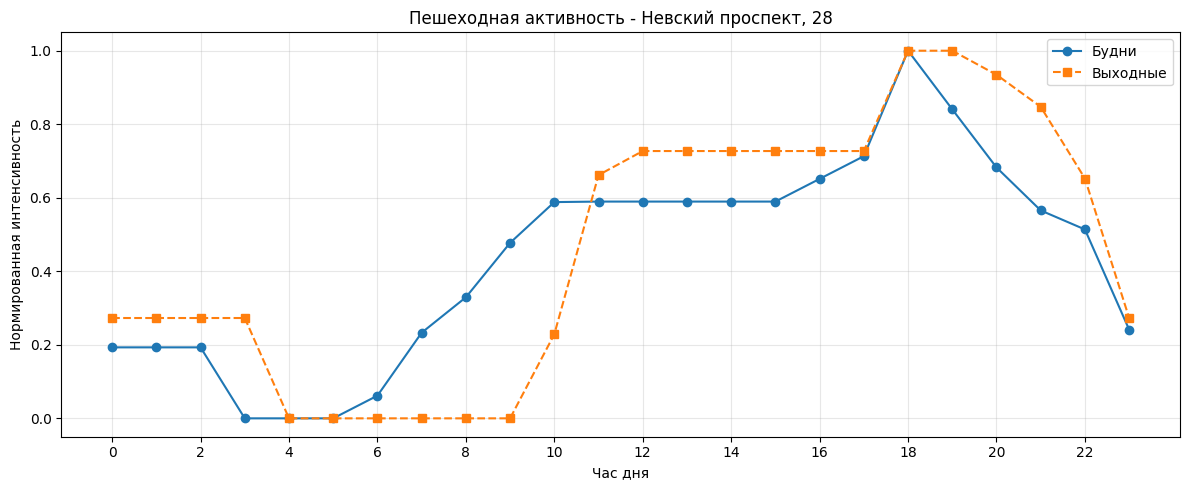

[2/5] Лиговский проспект, 50

Профиль трафика для Лиговский проспект, 50


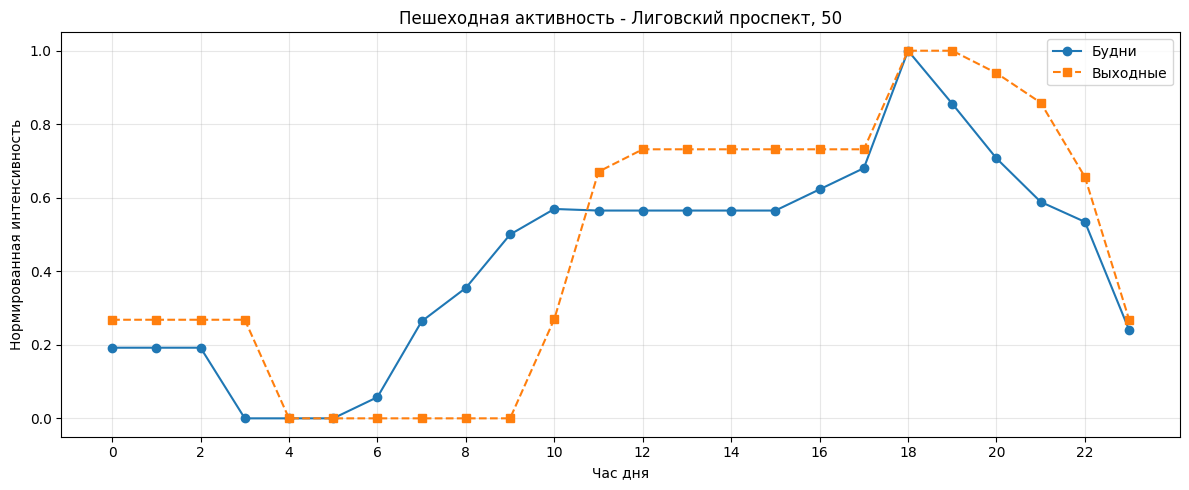

[3/5] Комендантский проспект, 13

Профиль трафика для Комендантский проспект, 13


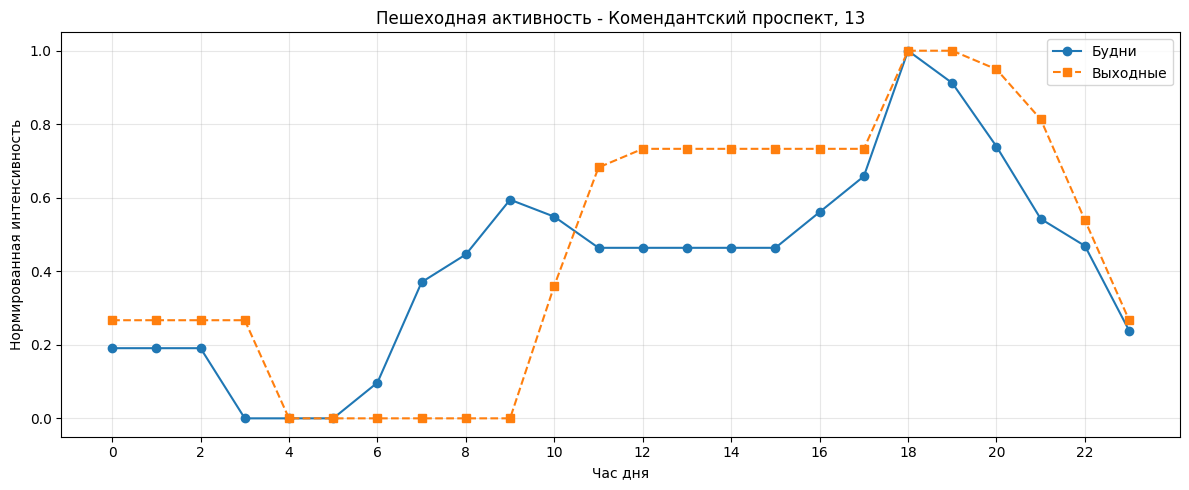

[4/5] Большой проспект П.С., 42

Профиль трафика для Большой проспект П.С., 42


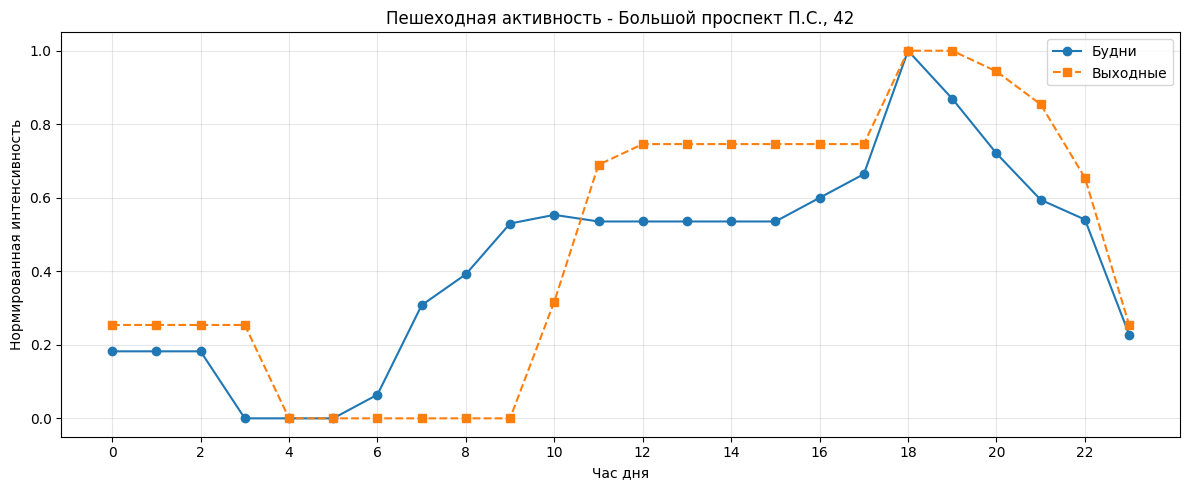

[5/5] Московский проспект, 103

Профиль трафика для Московский проспект, 103


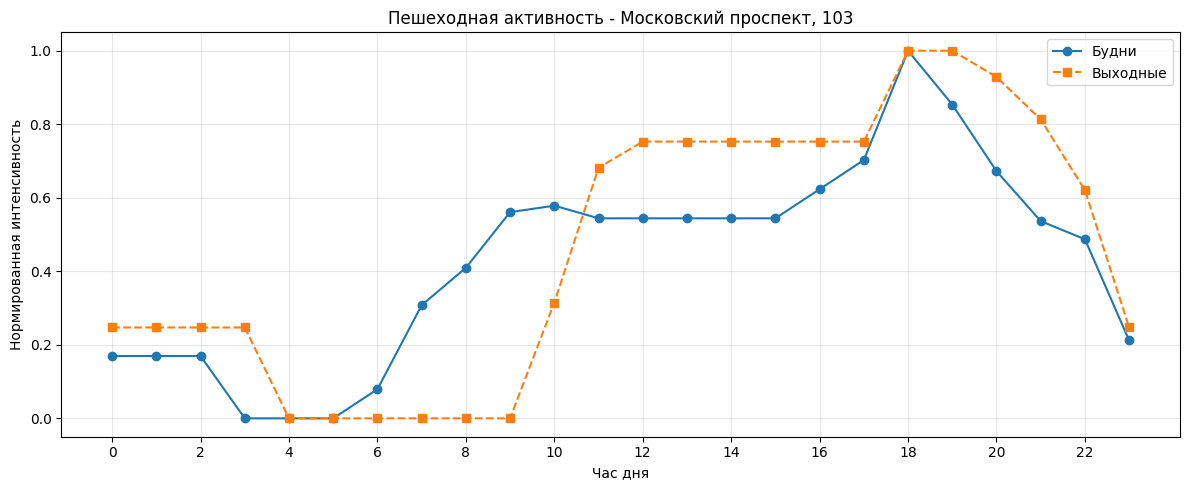

,address,commercial_score,commercial_class,assortment,positioning,risks
0,"Невский проспект, 28",69.92,medium,"Усилить посадочную зону, предложить specialty-...",Позиционировать как удобную остановку по пути ...,Высокая локальная конкуренция: нужен дифференц...
1,"Большой проспект П.С., 42",63.28,medium,"Усилить посадочную зону, предложить specialty-...",Позиционировать как удобную остановку по пути ...,Высокая локальная конкуренция: нужен дифференц...
2,"Комендантский проспект, 13",54.39,medium,"Усилить посадочную зону, предложить specialty-...",Позиционировать как удобную остановку по пути ...,Высокая локальная конкуренция: нужен дифференц...
3,"Московский проспект, 103",51.73,medium,"Усилить посадочную зону, предложить specialty-...",Позиционировать как удобную остановку по пути ...,Высокая локальная конкуренция: нужен дифференц...
4,"Лиговский проспект, 50",43.30,medium,"Усилить посадочную зону, предложить specialty-...",Позиционировать как удобную остановку по пути ...,Высокая локальная конкуренция: нужен дифференц...


In [99]:
comparison_df = compare_locations_unsupervised(
    addresses=test_addresses,
    business_type="coffee_shop",
    context=fast_context,
    scaler_unsup=scaler_unsup,
    pca_model=pca_model,
    kmeans_model=kmeans_model,
    feature_ranges=feature_ranges,
    cluster_labels=CLUSTER_LABELS,
    verbose=True,
    show_plots=True   # покажет графики
)

display(comparison_df[["address", "commercial_score", "commercial_class", "assortment", "positioning", "risks"]].head())